In [71]:
import pandas as pd
from pathlib import Path
from bin import utils, spd2xyz, plotting


In [72]:
# Set this to one CSV path or a list of CSV paths
files = [Path("/Users/loggiasr/Downloads/mt2tabsmeasured/Curiosity_spec_webcolor.csv"),
              Path("/Users/loggiasr/Downloads/mt2tabsmeasured/Voyager_spec_webcolor.csv"),
              Path("/Users/loggiasr/Downloads/mt2tabsmeasured/Sputnik_spec_webcolor.csv"),
              Path("/Users/loggiasr/Downloads/mt2tabsmeasured/Apollo_spec_webcolor.csv"),]


In [73]:
tmp_dir = Path("tmp")
tmp_dir.mkdir(parents=True, exist_ok=True)

xyz_files = []
for f in files:
    f = Path(f)
    out_xyz = tmp_dir / f"{f.stem}_measured_XYZ.csv"
    spd2xyz.convert_spd_csv_to_xyz(f, out_xyz)
    xyz_files.append(out_xyz)

print("Generated XYZ files:")
for xf in xyz_files:
    print(" -", xf)

valid, summary = utils.summarize_xyz_measurements(xyz_files)
summary


Generated XYZ files:
 - tmp/Curiosity_spec_webcolor_measured_XYZ.csv
 - tmp/Voyager_spec_webcolor_measured_XYZ.csv
 - tmp/Sputnik_spec_webcolor_measured_XYZ.csv
 - tmp/Apollo_spec_webcolor_measured_XYZ.csv


,id,n,X_mean,X_std,Y_mean,Y_std,Z_mean,Z_std
0,0,4,0.389799,0.027121,0.403430,0.026385,0.562823,0.048692
1,1,4,0.000364,0.000063,0.000354,0.000071,0.000748,0.000132
2,2,4,0.167760,0.012363,0.173441,0.013585,0.247272,0.019632
3,3,4,0.096587,0.006698,0.082740,0.006489,0.107447,0.007502
4,4,4,0.079294,0.006020,0.082163,0.006943,0.060580,0.006181
5,5,4,0.061867,0.004943,0.080807,0.007107,0.067082,0.006323
6,7,4,0.078151,0.006031,0.082301,0.007156,0.178113,0.013140
7,8,4,0.097792,0.007102,0.082390,0.006499,0.170207,0.012439
8,9,4,0.182323,0.014023,0.162241,0.013055,0.221854,0.019083
9,10,4,0.157352,0.012118,0.161689,0.013276,0.152911,0.013399


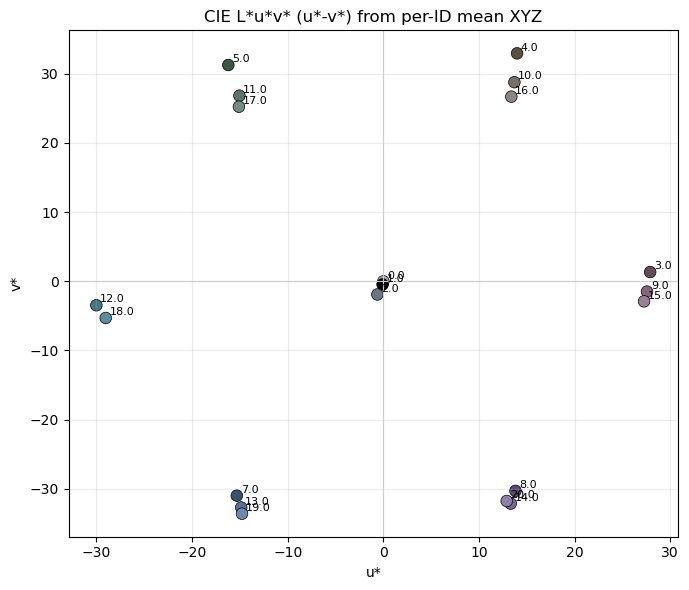

,group,ids,u_mean,v_mean,L_min,L_middle,L_max,n
0,GREY,[2],-0.628234,-1.903783,71.549359,71.549359,71.549359,1
1,RED,"[3, 9, 15]",27.572508,-1.016707,52.407913,69.622636,81.857671,3
2,YELLOW,"[4, 10, 16]",13.686052,29.475658,52.248630,69.525397,81.482457,3
3,GREEN,"[5, 11, 17]",-15.454285,27.780390,51.871095,69.324757,81.339391,3
4,CYAN,"[6, 12, 18]",-29.519459,-4.384939,69.456684,81.328864,81.328864,2
5,BLUE,"[7, 13, 19]",-14.987774,-32.426731,52.286862,69.757293,81.621641,3
6,MAGENTA,"[8, 14, 20]",13.340776,-31.397502,52.311358,69.854925,81.745073,3


In [74]:
import numpy as np
import matplotlib.pyplot as plt

# Explicit group mapping by ID
group_ids = {
    "GREY": [2],
    "RED": [3, 9, 15],
    "YELLOW": [4, 10, 16],
    "GREEN": [5, 11, 17],
    "CYAN": [6, 12, 18],
    "BLUE": [7, 13, 19],
    "MAGENTA": [8, 14, 20],
}

WHITE_ID = 0
# Load calibration model for new screen
cal = utils.XYZRGBScreenModel.load_json("spec_output/mt2_screen_model_2026.json")

# Per-ID mean XYZ values
xyz_means = summary[["X_mean", "Y_mean", "Z_mean"]].to_numpy()
id_num = pd.to_numeric(summary["id"], errors="coerce")

# Reference for L*u*v*: average XYZ of the GREY IDs
white_mask = id_num.isin([WHITE_ID])
if white_mask.any():
    reference_point = summary.loc[white_mask, ["X_mean", "Y_mean", "Z_mean"]].mean().to_numpy()
else:
    reference_point = xyz_means.mean(axis=0)
    print("Warning: No GREY IDs found in summary; using global mean XYZ as reference_point.")

luv = utils.xyz_to_cie_luv(xyz_means, reference_point)
luv_plot = pd.concat([summary[["id"]].reset_index(drop=True), luv[["L", "u", "v"]]], axis=1)
luv_plot["id_num"] = pd.to_numeric(luv_plot["id"], errors="coerce")

def xyz_to_srgb_approx(xyz):
    """Approximate XYZ (D65) to display-ready sRGB in [0,1]."""
    xyz = np.asarray(xyz, dtype=float)
    if np.nanmax(xyz) > 1.5:
        xyz = xyz / 100.0

    M = np.array([
        [ 3.2406, -1.5372, -0.4986],
        [-0.9689,  1.8758,  0.0415],
        [ 0.0557, -0.2040,  1.0570],
    ])
    rgb_linear = xyz @ M.T
    rgb_linear = np.clip(rgb_linear, 0.0, None)

    a = 0.055
    rgb = np.where(
        rgb_linear <= 0.0031308,
        12.92 * rgb_linear,
        (1 + a) * np.power(rgb_linear, 1 / 2.4) - a,
    )
    return np.clip(rgb, 0.0, 1.0)

point_colors = xyz_to_srgb_approx(xyz_means)

plt.figure(figsize=(7, 6))
plt.scatter(
    luv_plot["u"],
    luv_plot["v"],
    s=70,
    c=point_colors,
    edgecolors="black",
    linewidths=0.5,
)
for _, row in luv_plot.iterrows():
    plt.text(row["u"] + 0.4, row["v"] + 0.4, str(row["id"]), fontsize=8)

plt.xlabel("u*")
plt.ylabel("v*")
plt.title("CIE L*u*v* (u*-v*) from per-ID mean XYZ")
plt.axhline(0, color="0.8", linewidth=0.8)
plt.axvline(0, color="0.8", linewidth=0.8)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

rows = []
for group_name, ids in group_ids.items():
    g = luv_plot[luv_plot["id_num"].isin(ids)].copy()

    if g.empty:
        rows.append({
            "group": group_name,
            "ids": ids,
            "u_mean": np.nan,
            "v_mean": np.nan,
            "L_min": np.nan,
            "L_middle": np.nan,
            "L_max": np.nan,
            "n": 0,
        })
        continue

    L_sorted = np.sort(g["L"].to_numpy())
    L_middle = L_sorted[len(L_sorted) // 2]

    rows.append({
        "group": group_name,
        "ids": ids,
        "u_mean": g["u"].mean(),
        "v_mean": g["v"].mean(),
        "L_min": L_sorted.min(),
        "L_middle": L_middle,
        "L_max": L_sorted.max(),
        "n": len(g),
    })

group_stats = pd.DataFrame(rows)
group_stats


In [75]:
import numpy as np
import pandas as pd

required = ["summary", "group_ids", "WHITE_ID", "luv_plot"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run prior cells first; missing: {missing}")

id_num = pd.to_numeric(summary["id"], errors="coerce")
white_rows = summary.loc[id_num.isin([WHITE_ID]), ["Y_mean"]]
if white_rows.empty:
    raise RuntimeError(f"No white-point rows found for WHITE_ID={WHITE_ID}.")

Yn = float(white_rows["Y_mean"].mean())
if Yn <= 0:
    raise RuntimeError(f"Computed white Y (Yn) is invalid: {Yn}")

# Per-ID relative luminance from XYZ (Y/Yn).
rel = summary[["id", "X_mean", "Y_mean", "Z_mean"]].copy()
rel["id_num"] = pd.to_numeric(rel["id"], errors="coerce")
rel["Y_rel_to_white"] = rel["Y_mean"] / Yn

# Optional cross-check: infer Y/Yn from L* in luv_plot.
check = luv_plot[["id_num", "L"]].copy()
rel = rel.merge(check, on="id_num", how="left")

epsilon = 216 / 24389
kappa = 24389 / 27
rel["Y_rel_from_L"] = np.where(
    rel["L"] > 8,
    np.power((rel["L"] + 16) / 116, 3),
    rel["L"] / kappa,
)

# GREY relative luminance.
grey_ids = group_ids.get("GREY", [])
grey_rel = rel.loc[rel["id_num"].isin(grey_ids), "Y_rel_to_white"]
grey_rel_mean = float(grey_rel.mean()) if len(grey_rel) else np.nan

# For each non-grey group, assign low/mid/high by sorting Y/Yn within the 3 IDs.
records = []
for group_name, ids in group_ids.items():
    if group_name == "GREY":
        continue

    g = rel.loc[rel["id_num"].isin(ids), ["id", "id_num", "Y_rel_to_white", "Y_rel_from_L"]].copy()
    g = g.sort_values("Y_rel_to_white").reset_index(drop=True)

    if len(g) == 0:
        continue

    if len(g) == 1:
        level_labels = ["mid"]
    elif len(g) == 2:
        level_labels = ["low", "high"]
    else:
        level_labels = ["low", "mid", "high"] + [f"extra_{i}" for i in range(len(g) - 3)]

    g["level"] = level_labels[: len(g)]
    g["group"] = group_name
    records.append(g)

if not records:
    raise RuntimeError("No non-GREY groups had valid rows for relative luminance summary.")

per_group_levels = pd.concat(records, ignore_index=True)
level_summary = (
    per_group_levels.groupby("level", as_index=False)
    .agg(
        n=("Y_rel_to_white", "size"),
        Y_rel_mean=("Y_rel_to_white", "mean"),
        Y_rel_min=("Y_rel_to_white", "min"),
        Y_rel_max=("Y_rel_to_white", "max"),
        Y_rel_from_L_mean=("Y_rel_from_L", "mean"),
    )
)

print(f"White reference Yn (from WHITE_ID={WHITE_ID}): {Yn:.6f}")
print(f"Grey relative luminance Y/Yn (mean over GREY ids {grey_ids}): {grey_rel_mean:.6f}")
print("Mean relative luminance by level across non-GREY groups:")
display(level_summary.sort_values("level"))
print("Per-group low/mid/high assignment (sorted by Y/Yn within each group):")
display(per_group_levels[["group", "level", "id", "Y_rel_to_white", "Y_rel_from_L"]].sort_values(["group", "level"]))


White reference Yn (from WHITE_ID=0): 0.403430
Grey relative luminance Y/Yn (mean over GREY ids [2]): 0.429917
Mean relative luminance by level across non-GREY groups:


,level,n,Y_rel_mean,Y_rel_min,Y_rel_max,Y_rel_from_L_mean
0,high,6,0.594950,0.590678,0.600358,0.594950
1,low,6,0.236183,0.200300,0.399820,0.236183
2,mid,5,0.402080,0.397971,0.405435,0.402080


Per-group low/mid/high assignment (sorted by Y/Yn within each group):


,group,level,id,Y_rel_to_white,Y_rel_from_L
13,BLUE,high,19,0.596025,0.596025
11,BLUE,low,7,0.204003,0.204003
12,BLUE,mid,13,0.404054,0.404054
10,CYAN,high,18,0.590678,0.590678
9,CYAN,low,12,0.399820,0.399820
8,GREEN,high,17,0.590870,0.590870
6,GREEN,low,5,0.200300,0.200300
7,GREEN,mid,11,0.397971,0.397971
16,MAGENTA,high,20,0.598289,0.598289
14,MAGENTA,low,8,0.204223,0.204223


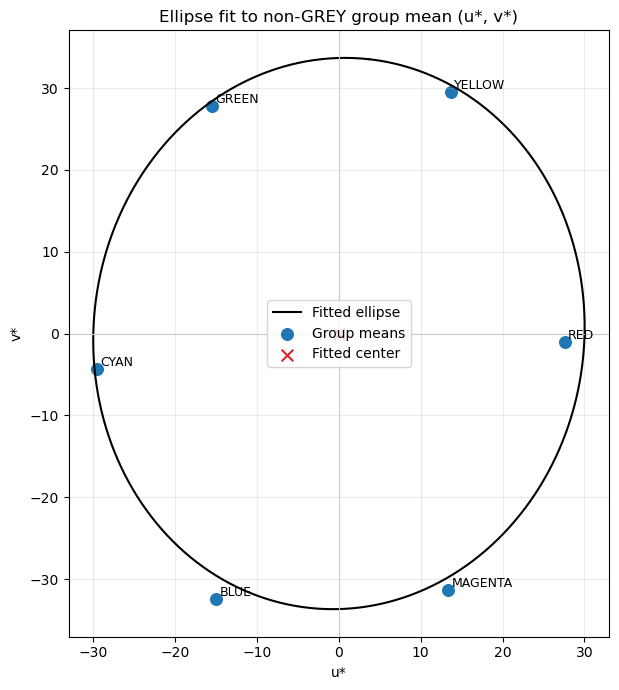

,group,u,v,rho,ellipse_residual
0,RED,27.572508,-1.016707,0.919835,-0.080165
1,YELLOW,13.686052,29.475658,0.976924,-0.023076
2,GREEN,-15.454285,27.780390,0.983274,-0.016726
3,CYAN,-29.519459,-4.384939,0.988796,-0.011204
4,BLUE,-14.987774,-32.426731,1.073669,0.073669
5,MAGENTA,13.340776,-31.397502,1.042840,0.042840


In [76]:
import numpy as np
import matplotlib.pyplot as plt
# Fit ellipse to color-group mean u,v points (excluding GREY)
non_grey = group_stats.loc[
    (group_stats["group"] != "GREY")
    & group_stats["u_mean"].notna()
    & group_stats["v_mean"].notna(),
    ["group", "u_mean", "v_mean"],
].reset_index(drop=True)
uv_means = non_grey[["u_mean", "v_mean"]].to_numpy()
# Increase circularity_weight to bias toward a more circular ellipse
circularity_weight = 0.1
fit_uv = utils.fit_uv_ellipse(
    uv_means,
    center_weight=1.0,
    axis_balance_weight=circularity_weight,
)
fit_uv_summary = {k: v for k, v in fit_uv.items() if k != "point_table"}
fit_uv_points = fit_uv["point_table"].copy()
fit_uv_points["group"] = non_grey["group"].to_numpy()
fit_uv_points = fit_uv_points[["group", "u", "v", "rho", "ellipse_residual"]]
theta = np.linspace(0, 2 * np.pi, 600)
ellipse_xy = utils.ellipse_uv_from_t(fit_uv, theta)
plt.figure(figsize=(7, 7))
plt.plot(ellipse_xy[:, 0], ellipse_xy[:, 1], color="black", linewidth=1.5, label="Fitted ellipse")
plt.scatter(non_grey["u_mean"], non_grey["v_mean"], s=70, color="tab:blue", label="Group means")
plt.scatter([fit_uv["center_u"]], [fit_uv["center_v"]], s=70, color="tab:red", marker="x", label="Fitted center")
for _, row in non_grey.iterrows():
    plt.text(row["u_mean"] + 0.4, row["v_mean"] + 0.4, row["group"], fontsize=9)
plt.xlabel("u*")
plt.ylabel("v*")
plt.title("Ellipse fit to non-GREY group mean (u*, v*)")
plt.axhline(0, color="0.8", linewidth=0.8)
plt.axvline(0, color="0.8", linewidth=0.8)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()
fit_uv_summary
fit_uv_points


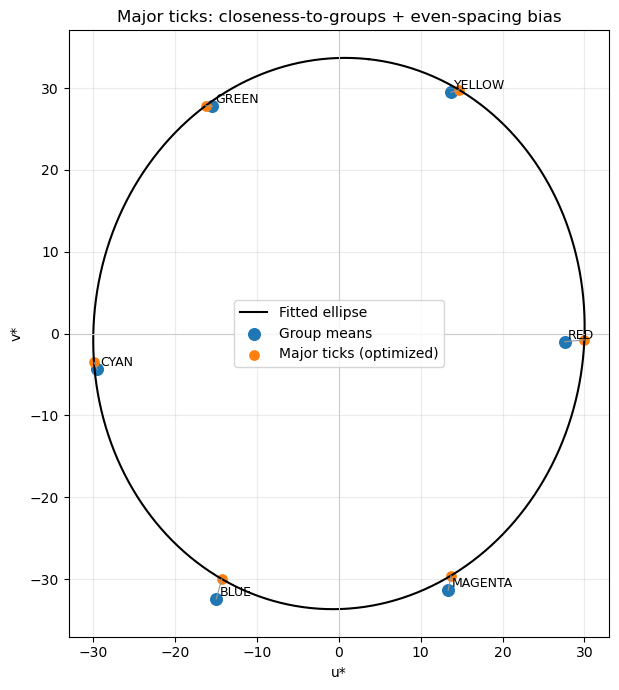

direction_sign = 1
major_even_spacing_weight = 0.25
major gap arc lengths = [35.834 33.004 35.598 31.988 29.436 34.445]


,group,u_mean,v_mean,u_proj,v_proj,distance
0,RED,27.572508,-1.016707,29.991158,-0.772154,2.430983
1,YELLOW,13.686052,29.475658,14.691375,29.774678,1.048851
2,GREEN,-15.454285,27.780390,-16.299557,27.825146,0.846456
3,CYAN,-29.519459,-4.384939,-29.931355,-3.509527,0.967473
4,BLUE,-14.987774,-32.426731,-14.315882,-29.998403,2.519567
5,MAGENTA,13.340776,-31.397502,13.705945,-29.578595,1.855201


In [77]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize

# Use fitted ellipse and group means from previous cell
if "fit_uv" not in globals() or "non_grey" not in globals():
    raise RuntimeError("Run the previous cell (ellipse fit) first.")

group_order = ["RED", "YELLOW", "GREEN", "CYAN", "BLUE", "MAGENTA"]
ordered = non_grey.set_index("group").reindex(group_order).reset_index()
if ordered[["u_mean", "v_mean"]].isna().any().any():
    missing = ordered.loc[ordered[["u_mean", "v_mean"]].isna().any(axis=1), "group"].tolist()
    raise RuntimeError(f"Missing group means for: {missing}")

means_uv = ordered[["u_mean", "v_mean"]].to_numpy(dtype=float)
n_major = len(means_uv)

# Initial closest-point projections (used for initialization and orientation)
proj0 = utils.project_uv_to_ellipse(means_uv, fit_uv)
t_raw = proj0["t"].to_numpy(dtype=float)

def _forward_deltas(t, sign):
    deltas = [float(np.mod(sign * (t[i] - t[i - 1]), 2 * np.pi)) for i in range(1, len(t))]
    deltas.append(float(np.mod(sign * (t[0] - t[-1]), 2 * np.pi)))
    return np.array(deltas, dtype=float)

expected_step_t = 2 * np.pi / n_major
d_plus = _forward_deltas(t_raw, +1.0)
d_minus = _forward_deltas(t_raw, -1.0)
score_plus = abs(d_plus.mean() - expected_step_t)
score_minus = abs(d_minus.mean() - expected_step_t)
direction_sign = -1.0 if score_minus < score_plus else 1.0

t_anchor = float(t_raw[0])  # RED anchor

# Build lookup between path parameter u in [0, 2pi] and arc length s in [0, C]
ellipse_path_u_grid = np.linspace(0.0, 2.0 * np.pi, 5001)
actual_t_grid = t_anchor + direction_sign * ellipse_path_u_grid
ellipse_path_xy_grid = utils.ellipse_uv_from_t(fit_uv, actual_t_grid)
ds_grid = np.sqrt(((ellipse_path_xy_grid[1:] - ellipse_path_xy_grid[:-1]) ** 2).sum(axis=1))
ellipse_path_s_grid = np.r_[0.0, np.cumsum(ds_grid)]
ellipse_circumference = float(ellipse_path_s_grid[-1])

def _u_to_s(u):
    return np.interp(np.mod(u, 2 * np.pi), ellipse_path_u_grid, ellipse_path_s_grid)

def _s_to_u(s):
    return np.interp(np.mod(s, ellipse_circumference), ellipse_path_s_grid, ellipse_path_u_grid)

def _xy_from_s(s):
    u = _s_to_u(np.asarray(s, dtype=float))
    t = t_anchor + direction_sign * u
    return utils.ellipse_uv_from_t(fit_uv, t)

# Initial s-positions from raw projections
u_raw = np.mod(direction_sign * (t_raw - t_anchor), 2 * np.pi)
s_raw = _u_to_s(u_raw)
raw_gaps = np.array([np.mod(s_raw[(i + 1) % n_major] - s_raw[i], ellipse_circumference) for i in range(n_major)])

def _softmax(z):
    z = z - np.max(z)
    ez = np.exp(z)
    return ez / ez.sum()

# Tunable: higher -> more even major spacing, lower -> closer to group means
major_even_spacing_weight = 0.25

def _unpack(x):
    s0 = float(np.mod(x[0], ellipse_circumference))
    gaps = ellipse_circumference * _softmax(x[1:])
    s_unwrap = s0 + np.r_[0.0, np.cumsum(gaps[:-1])]
    s_mod = np.mod(s_unwrap, ellipse_circumference)
    xy = _xy_from_s(s_mod)
    return s_unwrap, s_mod, gaps, xy

def _objective(x):
    _, _, gaps, xy = _unpack(x)
    data_term = np.mean(((xy - means_uv) ** 2).sum(axis=1))
    spacing_term = np.mean((gaps - (ellipse_circumference / n_major)) ** 2)
    return float(data_term + major_even_spacing_weight * spacing_term)

x0 = np.r_[s_raw[0], np.log(np.clip(raw_gaps, 1e-9, None))]
res = minimize(_objective, x0, method="L-BFGS-B", options={"maxiter": 2000})

major_s_unwrap, major_s_mod, major_gaps, major_xy = _unpack(res.x)
major_dist = np.sqrt(((major_xy - means_uv) ** 2).sum(axis=1))

phase_alignment = ordered.copy()
phase_alignment["u_proj"] = major_xy[:, 0]
phase_alignment["v_proj"] = major_xy[:, 1]
phase_alignment["distance"] = major_dist
phase_alignment["path_s"] = major_s_unwrap
phase_alignment["direction_sign"] = direction_sign
phase_alignment["t_anchor"] = t_anchor
phase_alignment["ellipse_circumference"] = ellipse_circumference
phase_alignment["major_even_spacing_weight"] = major_even_spacing_weight

tick_table = pd.DataFrame({
    "tick": np.arange(n_major, dtype=int),
    "group": phase_alignment["group"],
    "u_tick": phase_alignment["u_proj"],
    "v_tick": phase_alignment["v_proj"],
    "path_s": phase_alignment["path_s"],
})

theta = np.linspace(0, 2 * np.pi, 800)
ellipse_xy = utils.ellipse_uv_from_t(fit_uv, theta)

plt.figure(figsize=(7, 7))
plt.plot(ellipse_xy[:, 0], ellipse_xy[:, 1], color="black", linewidth=1.5, label="Fitted ellipse")
plt.scatter(phase_alignment["u_mean"], phase_alignment["v_mean"], s=70, color="tab:blue", label="Group means")
plt.scatter(phase_alignment["u_proj"], phase_alignment["v_proj"], s=45, color="tab:orange", label="Major ticks (optimized)")
for _, row in phase_alignment.iterrows():
    plt.plot([row["u_mean"], row["u_proj"]], [row["v_mean"], row["v_proj"]], color="0.6", linewidth=0.8)
    plt.text(row["u_mean"] + 0.4, row["v_mean"] + 0.4, row["group"], fontsize=9)
plt.xlabel("u*")
plt.ylabel("v*")
plt.title("Major ticks: closeness-to-groups + even-spacing bias")
plt.axhline(0, color="0.8", linewidth=0.8)
plt.axvline(0, color="0.8", linewidth=0.8)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.25)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

print(f"direction_sign = {int(direction_sign)}")
print(f"major_even_spacing_weight = {major_even_spacing_weight}")
print(f"major gap arc lengths = {np.round(major_gaps, 3)}")
tick_table
phase_alignment[["group", "u_mean", "v_mean", "u_proj", "v_proj", "distance"]]


In [78]:
import numpy as np
import pandas as pd

required = ["tick_table", "phase_alignment", "fit_uv", "ellipse_path_u_grid", "ellipse_path_s_grid", "ellipse_circumference"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run the previous cell first; missing: {missing}")

direction_sign = float(phase_alignment["direction_sign"].iloc[0])
t_anchor = float(phase_alignment["t_anchor"].iloc[0])
ellipse_circumference = float(phase_alignment["ellipse_circumference"].iloc[0])
n_major = len(tick_table)
if n_major != 6:
    raise RuntimeError(f"Expected 6 major ticks, found {n_major}.")

def _s_to_u(s):
    return np.interp(np.mod(s, ellipse_circumference), ellipse_path_s_grid, ellipse_path_u_grid)

def _ellipse_from_path_s(path_s):
    u = _s_to_u(np.asarray(path_s, dtype=float))
    actual_t = t_anchor + direction_sign * u
    return utils.ellipse_uv_from_t(fit_uv, actual_t)

rows = []
for i in range(n_major):
    s0 = float(tick_table.loc[i, "path_s"])
    if i < n_major - 1:
        s1 = float(tick_table.loc[i + 1, "path_s"])
    else:
        s1 = float(tick_table.loc[0, "path_s"] + ellipse_circumference)

    # 6 ticks per segment: major(start) + 5 interior
    s_ticks = s0 + (s1 - s0) * (np.arange(6, dtype=float) / 6.0)
    xy_ticks = _ellipse_from_path_s(s_ticks)

    for j in range(6):
        rows.append({
            "ID": i * 6 + j,
            "segment_idx": i,
            "segment_start": tick_table.loc[i, "group"],
            "segment_end": tick_table.loc[(i + 1) % n_major, "group"],
            "is_major": (j == 0),
            "path_s": float(s_ticks[j]),
            "U": float(xy_ticks[j, 0]),
            "V": float(xy_ticks[j, 1]),
        })

uv36_full = pd.DataFrame(rows).sort_values("ID").reset_index(drop=True)
uv36 = uv36_full[["ID", "U", "V"]].copy()

tick_uv = tick_table[["tick", "group", "u_tick", "v_tick"]].rename(
    columns={"tick": "Tick", "u_tick": "U", "v_tick": "V", "group": "Group"}
)

print("Created 36 ticks total: 6 major (included in uv36) + 30 non-major.")
print("ID 0 is the RED major tick.")
tick_uv
uv36
uv36_full[["ID", "segment_start", "segment_end", "is_major", "path_s"]]


Created 36 ticks total: 6 major (included in uv36) + 30 non-major.
ID 0 is the RED major tick.


,ID,segment_start,segment_end,is_major,path_s
0,0,RED,YELLOW,True,0.370662
1,1,RED,YELLOW,False,6.342945
2,2,RED,YELLOW,False,12.315228
3,3,RED,YELLOW,False,18.287510
4,4,RED,YELLOW,False,24.259793
5,5,RED,YELLOW,False,30.232076
6,6,YELLOW,GREEN,True,36.204359
7,7,YELLOW,GREEN,False,41.705011
8,8,YELLOW,GREEN,False,47.205663
9,9,YELLOW,GREEN,False,52.706315


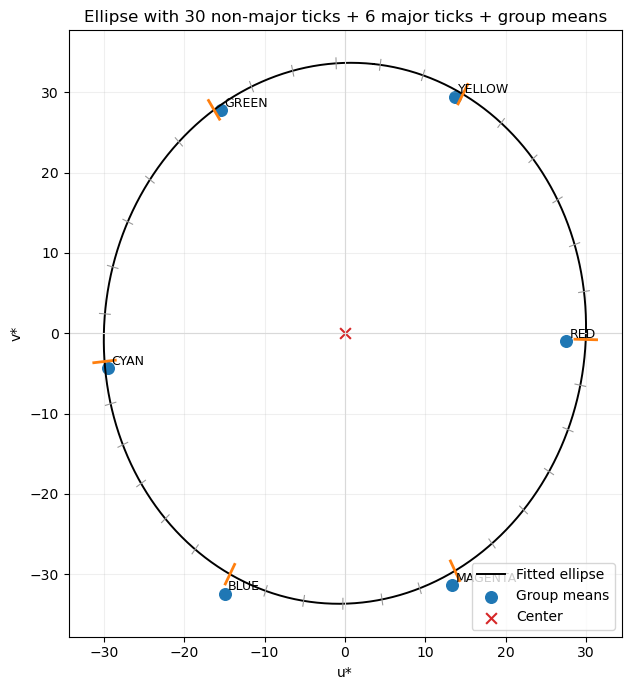

In [79]:
import numpy as np
import matplotlib.pyplot as plt

required = ["fit_uv", "tick_table", "uv36", "non_grey"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run prior cells first; missing: {missing}")

cu = float(fit_uv["center_u"])
cv = float(fit_uv["center_v"])
a = float(fit_uv["axis_a"])
b = float(fit_uv["axis_b"])

theta = np.linspace(0, 2 * np.pi, 800)
ellipse_xy = utils.ellipse_uv_from_t(fit_uv, theta)

plt.figure(figsize=(7, 7))
plt.plot(ellipse_xy[:, 0], ellipse_xy[:, 1], color="black", linewidth=1.4, label="Fitted ellipse")

minor_len = 0.02 * max(a, b)
major_len = 0.04 * max(a, b)

if "uv36_full" in globals() and "is_major" in uv36_full.columns:
    minor_only = uv36_full.loc[~uv36_full["is_major"], ["U", "V"]]
else:
    minor_only = uv36.loc[uv36["ID"] % 6 != 0, ["U", "V"]]

# 30 non-major ticks (thin gray lines)
for _, row in minor_only.iterrows():
    du = row["U"] - cu
    dv = row["V"] - cv
    n = np.hypot(du, dv)
    if n == 0:
        continue
    ux, vy = du / n, dv / n
    x1, y1 = row["U"] - minor_len * ux, row["V"] - minor_len * vy
    x2, y2 = row["U"] + minor_len * ux, row["V"] + minor_len * vy
    plt.plot([x1, x2], [y1, y2], color="0.6", linewidth=0.8)

# 6 major ticks (thicker orange lines)
for _, row in tick_table.iterrows():
    du = row["u_tick"] - cu
    dv = row["v_tick"] - cv
    n = np.hypot(du, dv)
    if n == 0:
        continue
    ux, vy = du / n, dv / n
    x1, y1 = row["u_tick"] - major_len * ux, row["v_tick"] - major_len * vy
    x2, y2 = row["u_tick"] + major_len * ux, row["v_tick"] + major_len * vy
    plt.plot([x1, x2], [y1, y2], color="tab:orange", linewidth=2.0)

plt.scatter(non_grey["u_mean"], non_grey["v_mean"], s=70, color="tab:blue", label="Group means")
for _, row in non_grey.iterrows():
    plt.text(row["u_mean"] + 0.4, row["v_mean"] + 0.4, row["group"], fontsize=9)

plt.scatter([cu], [cv], s=60, color="tab:red", marker="x", label="Center")
plt.xlabel("u*")
plt.ylabel("v*")
plt.title("Ellipse with 30 non-major ticks + 6 major ticks + group means")
plt.axhline(0, color="0.85", linewidth=0.8)
plt.axvline(0, color="0.85", linewidth=0.8)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.2)
plt.legend(loc="best")
plt.tight_layout()
plt.show()


In [80]:
from pathlib import Path

if "uv36" not in globals():
    raise RuntimeError("Run the uv36 generation cell first.")

out_dir = Path("spec_output")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "mt2_target_uv_2026.tsv"

uv36.to_csv(out_path, sep="\t", index=False)
print(f"Saved {len(uv36)} rows to {out_path}")
out_path


Saved 36 rows to spec_output/mt2_target_uv_2026.tsv


PosixPath('spec_output/mt2_target_uv_2026.tsv')

In [81]:
import numpy as np
import pandas as pd

required = ["uv36", "tick_table", "uv36_full", "fit_uv", "phase_alignment", "ellipse_path_u_grid", "ellipse_path_s_grid"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run prior cells first; missing: {missing}")

direction_sign = float(phase_alignment["direction_sign"].iloc[0])
t_anchor = float(phase_alignment["t_anchor"].iloc[0])
ellipse_circumference = float(phase_alignment["ellipse_circumference"].iloc[0])
n_major = len(tick_table)

def _s_to_u(s):
    return np.interp(np.mod(s, ellipse_circumference), ellipse_path_s_grid, ellipse_path_u_grid)

def _ellipse_from_path_s(path_s):
    u = _s_to_u(np.asarray(path_s, dtype=float))
    actual_t = t_anchor + direction_sign * u
    return utils.ellipse_uv_from_t(fit_uv, actual_t)

rows = []
for i in range(n_major):
    seg_start = tick_table.loc[i, "group"]
    seg_end = tick_table.loc[(i + 1) % n_major, "group"]

    g = uv36_full.loc[uv36_full["segment_idx"] == i].sort_values("ID").reset_index(drop=True)
    if len(g) != 6:
        raise RuntimeError(f"Expected 6 ticks in segment {seg_start}->{seg_end}, found {len(g)}")

    # Append next segment major to measure 6 intervals in this segment
    if i < n_major - 1:
        next_major_id = int((i + 1) * 6)
        next_s = float(tick_table.loc[i + 1, "path_s"])
    else:
        next_major_id = 0
        next_s = float(tick_table.loc[0, "path_s"] + ellipse_circumference)

    next_major_uv = _ellipse_from_path_s([next_s])[0]

    u_pts = np.r_[g["U"].to_numpy(dtype=float), float(next_major_uv[0])]
    v_pts = np.r_[g["V"].to_numpy(dtype=float), float(next_major_uv[1])]
    id_pts = np.r_[g["ID"].to_numpy(dtype=int), next_major_id]
    s_pts = np.r_[g["path_s"].to_numpy(dtype=float), next_s]

    for j in range(6):
        p0 = np.array([u_pts[j], v_pts[j]], dtype=float)
        p1 = np.array([u_pts[j + 1], v_pts[j + 1]], dtype=float)
        chord = float(np.linalg.norm(p1 - p0))

        dense_s = np.linspace(s_pts[j], s_pts[j + 1], 600)
        dense_xy = _ellipse_from_path_s(dense_s)
        arc = float(np.sqrt(((dense_xy[1:] - dense_xy[:-1]) ** 2).sum(axis=1)).sum())

        rows.append({
            "segment_start": seg_start,
            "segment_end": seg_end,
            "interval_in_segment": j,
            "from_ID": int(id_pts[j]),
            "to_ID": int(id_pts[j + 1]),
            "chord_distance": chord,
            "arc_distance": arc,
        })

minor_tick_distances = pd.DataFrame(rows)
segment_distance_summary = minor_tick_distances.groupby(["segment_start", "segment_end"], as_index=False).agg(
    arc_mean=("arc_distance", "mean"),
    arc_min=("arc_distance", "min"),
    arc_max=("arc_distance", "max"),
    chord_mean=("chord_distance", "mean"),
    chord_min=("chord_distance", "min"),
    chord_max=("chord_distance", "max"),
    n_intervals=("arc_distance", "size"),
)

print("Distances between consecutive ticks within each adjacent color-group segment (6 intervals/segment):")
display(minor_tick_distances)
print("Per-segment summary (arc distance should be ~constant within each segment):")
display(segment_distance_summary)


Distances between consecutive ticks within each adjacent color-group segment (6 intervals/segment):


,segment_start,segment_end,interval_in_segment,from_ID,to_ID,chord_distance,arc_distance
0,RED,YELLOW,0,0,1,5.966010,5.972283
1,RED,YELLOW,1,1,2,5.965662,5.972284
2,RED,YELLOW,2,2,3,5.965049,5.972283
3,RED,YELLOW,3,3,4,5.964162,5.972283
4,RED,YELLOW,4,4,5,5.963029,5.972284
5,RED,YELLOW,5,5,6,5.961761,5.972283
6,YELLOW,GREEN,0,6,7,5.491559,5.500652
7,YELLOW,GREEN,1,7,8,5.491018,5.500652
8,YELLOW,GREEN,2,8,9,5.490941,5.500652
9,YELLOW,GREEN,3,9,10,5.491355,5.500652


Per-segment summary (arc distance should be ~constant within each segment):


,segment_start,segment_end,arc_mean,arc_min,arc_max,chord_mean,chord_min,chord_max,n_intervals
0,BLUE,MAGENTA,4.906017,4.906017,4.906017,4.899525,4.899107,4.900274,6
1,CYAN,BLUE,5.331305,5.331305,5.331305,5.325411,5.323705,5.326699,6
2,GREEN,CYAN,5.932952,5.932952,5.932952,5.926111,5.924528,5.926884,6
3,MAGENTA,RED,5.740864,5.740864,5.740865,5.734381,5.732666,5.735381,6
4,RED,YELLOW,5.972283,5.972283,5.972284,5.964279,5.961761,5.966010,6
5,YELLOW,GREEN,5.500652,5.500652,5.500652,5.491671,5.490941,5.493032,6


In [82]:
# compute white and grey point to match xyz from old screen (use same exact grey point xyz as old) 
screen_max = cal.white_xyz
white_point = reference_point
diff = white_point - screen_max
arg_m = np.argmax(diff)
ratio = screen_max[arg_m] / white_point[arg_m]
print(f"Screen max XYZ: {screen_max}")
print(f"Reference white XYZ: {white_point}")
print(f"Difference (white - screen_max): {diff}")
print(f"Max difference in channel {arg_m} with ratio {ratio:.3f}")
max_lum = white_point * ratio
print(f" max XYZ allowed on new screen (scaled from reference white): {max_lum}")
min_lum = 0, 0, 0
grey_point = summary.loc[summary["id"].isin(group_ids["GREY"]), ["X_mean", "Y_mean", "Z_mean"]].mean().to_numpy()
l_grey = np.mean(grey_point / max_lum)


Screen max XYZ: [0.39560008 0.43558724 0.39434888]
Reference white XYZ: [0.38979874 0.40342977 0.56282317]
Difference (white - screen_max): [-0.00580133 -0.03215747  0.16847428]
Max difference in channel 2 with ratio 0.701
 max XYZ allowed on new screen (scaled from reference white): [0.27311722 0.28266796 0.39434888]


In [83]:
step_size = (.83 - l_grey) / 10
print(step_size)
above = np.arange(l_grey, 0.84, step_size)
below = np.arange(l_grey, l_grey -.01 - step_size * 10, -step_size)
l_levels = np.concatenate([np.flip(below[1:]), above])
print(l_levels)

0.02117112701641608
[0.40657746 0.42774859 0.44891971 0.47009084 0.49126197 0.51243309
 0.53360422 0.55477535 0.57594648 0.5971176  0.61828873 0.63945986
 0.66063098 0.68180211 0.70297324 0.72414436 0.74531549 0.76648662
 0.78765775 0.80882887 0.83      ]


In [84]:
import numpy as np
import pandas as pd

required = ["uv36", "l_levels"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run prior cells first; missing: {missing}")

uv_base = uv36[["ID", "U", "V"]].sort_values("ID").reset_index(drop=True)
L_rel = np.asarray(l_levels, dtype=float)

n_levels = len(L_rel)
n_hues = len(uv_base)

hue_id = np.tile(uv_base["ID"].to_numpy(dtype=int), n_levels)
u_all = np.tile(uv_base["U"].to_numpy(dtype=float), n_levels)
v_all = np.tile(uv_base["V"].to_numpy(dtype=float), n_levels)
l_idx = np.repeat(np.arange(n_levels, dtype=int), n_hues)
l_rel_all = np.repeat(L_rel, n_hues)

# Flattened ID across all 21 luminance levels and 36 hue positions.
flat_id = l_idx * n_hues + hue_id

luv36_21 = np.column_stack([l_rel_all, u_all, v_all])

luv36_21_df = pd.DataFrame({
    "id": flat_id,
    "hue_id": hue_id,
    "l_idx": l_idx,
    "l_level": l_rel_all,
    "u": u_all,
    "v": v_all,
})

print(f"luv36_21 shape: {luv36_21.shape} (expected {n_levels} x {n_hues} = {n_levels*n_hues} rows)")
luv36_21_df.head()

luv36_21 shape: (756, 3) (expected 21 x 36 = 756 rows)


,id,hue_id,l_idx,l_level,u,v
0,0,0,0,0.406577,29.991158,-0.772154
1,1,1,0,0.406577,29.772401,5.189844
2,2,2,0,0.406577,28.602170,11.039604
3,3,3,0,0.406577,26.478061,16.613649
4,4,4,0,0.406577,23.414123,21.730631


In [85]:
import numpy as np
import pandas as pd

required = ["luv36_21_df", "max_lum"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run prior cells first; missing: {missing}")

# Interpret l_level as relative luminance (Y/Yn), then convert to CIE L*.
yr = np.clip(luv36_21_df["l_level"].to_numpy(dtype=float), 0.0, None)
epsilon = 216 / 24389
kappa = 24389 / 27
L_star = np.where(yr > epsilon, 116 * np.cbrt(yr) - 16, kappa * yr)

luv_values = np.column_stack([
    L_star,
    luv36_21_df["u"].to_numpy(dtype=float),
    luv36_21_df["v"].to_numpy(dtype=float),
])

xyz_conv = utils.cie_luv_to_xyz(luv_values, reference_point=max_lum)
xyz36_21 = pd.DataFrame({
    "id": luv36_21_df["id"].to_numpy(dtype=int),
    "x": xyz_conv["X"].to_numpy(dtype=float),
    "y": xyz_conv["Y"].to_numpy(dtype=float),
    "z": xyz_conv["Z"].to_numpy(dtype=float),
})

In [86]:
from pathlib import Path
import numpy as np
import pandas as pd

required = ["xyz36_21", "cal"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run prior cells first; missing: {missing}")

rgb = cal.xyz_to_rgb(xyz36_21[["x", "y", "z"]].to_numpy(dtype=float), clip=True, as_int=False)
rgb_int = np.clip(np.rint(rgb), 0, 255).astype(int)

rgb36_21 = pd.DataFrame({
    "id": xyz36_21["id"].to_numpy(dtype=int),
    "r": rgb_int[:, 0],
    "g": rgb_int[:, 1],
    "b": rgb_int[:, 2],
})

out_dir = Path("spec_output")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "mt2_target_rgb_2026.tsv"
rgb36_21.to_csv(out_path, sep="	", index=False)

print(f"Saved {len(rgb36_21)} RGB rows to {out_path}")
print("RGB channel min/max:")
print(rgb36_21[["r", "g", "b"]].agg(["min", "max"]))
rgb36_21.head()

Saved 756 RGB rows to spec_output/mt2_target_rgb_2026.tsv
RGB channel min/max:
       r    g    b
min  115  129  135
max  206  193  255


,id,r,g,b
0,0,155,129,163
1,1,154,129,158
2,2,153,130,153
3,3,151,131,148
4,4,149,131,144


In [87]:
required = ["xyz36_21", "rgb36_21", "luv36_21_df", "cal", "plotting"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run prior cells first; missing: {missing}")

grey_xyz = grey_point if "grey_point" in globals() else None
white_xyz = max_lum if "max_lum" in globals() else None
black_xyz = cal.black_xyz if hasattr(cal, "black_xyz") else None

fig_xyz = plotting.plot_xyz_gamut_with_levels(
    xyz_df=xyz36_21,
    rgb_df=rgb36_21,
    level_df=luv36_21_df[["id", "l_idx", "l_level", "hue_id"]],
    rgb_to_xyz_fn=cal.rgb_to_xyz,
    title="Screen gamut in XYZ with 36 hue points at low/mid/high luminance",
    tight_view=True,
    tight_pad_frac=0.01,
    tight_min_pad=0.05,
    camera_eye=(0.75, 0.75, 0.6),
)
fig_xyz.show()

In [88]:
required = ["luv36_21_df", "rgb36_21", "cal", "max_lum", "plotting", "utils"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run prior cells first; missing: {missing}")

fig_luv, luv_bounds = plotting.plot_luv_gamut_bounds_with_levels(
    luv_df=luv36_21_df,
    rgb_df=rgb36_21,
    rgb_to_xyz_fn=cal.rgb_to_xyz,
    xyz_to_luv_fn=utils.xyz_to_cie_luv,
    reference_xyz=max_lum,
    title="CIE L*u*v*: 36 colors at low/mid/high luminance with min/max gamut bounds",
    tight_view=True,
    tight_pad_frac=0.01,
    tight_min_pad=0.05,
    camera_eye=(0.75, 0.75, 0.6),
)
fig_luv.show()

print(f"L* range: [{luv_bounds['L_min']:.3f}, {luv_bounds['L_max']:.3f}]")
print(f"u* range: [{luv_bounds['u_min']:.3f}, {luv_bounds['u_max']:.3f}]")
print(f"v* range: [{luv_bounds['v_min']:.3f}, {luv_bounds['v_max']:.3f}]")

L* range: [0.915, 122.428]
u* range: [-161.018, 334.294]
v* range: [-114.478, 197.878]


In [89]:
# redefine grey point to be optimal for new screen (instead of using old screen grey point) and recompute L* levels based on that
s_range = cal.white_xyz - cal.black_xyz
# determing luminance levels
# we want to set this such as to produce a minimum lum (Y) of around .06 and a maximum Y of around .32 with grey around .19
l_levels = np.linspace(.15, .74, 21)
new_grey_point = cal.black_xyz + l_levels[10] * s_range

print(l_levels)


[0.15   0.1795 0.209  0.2385 0.268  0.2975 0.327  0.3565 0.386  0.4155
 0.445  0.4745 0.504  0.5335 0.563  0.5925 0.622  0.6515 0.681  0.7105
 0.74  ]


In [90]:
# cie for new screen, idealized
required = ["uv36", "l_levels"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run prior cells first; missing: {missing}")

uv_base = uv36[["ID", "U", "V"]].sort_values("ID").reset_index(drop=True)
L_rel = np.asarray(l_levels, dtype=float)

n_levels = len(L_rel)
n_hues = len(uv_base)

hue_id = np.tile(uv_base["ID"].to_numpy(dtype=int), n_levels)
u_all = np.tile(uv_base["U"].to_numpy(dtype=float), n_levels)
v_all = np.tile(uv_base["V"].to_numpy(dtype=float), n_levels)
l_idx = np.repeat(np.arange(n_levels, dtype=int), n_hues)
l_rel_all = np.repeat(L_rel, n_hues)

# Flattened ID across all 21 luminance levels and 36 hue positions.
flat_id = l_idx * n_hues + hue_id

new_luv36_21 = np.column_stack([l_rel_all, u_all, v_all])

new_luv36_21_df = pd.DataFrame({
    "id": flat_id,
    "hue_id": hue_id,
    "l_idx": l_idx,
    "l_level": l_rel_all,
    "u": u_all,
    "v": v_all,
})

# Interpret l_level as relative luminance (Y/Yn), then convert to CIE L*.
yr = np.clip(new_luv36_21_df["l_level"].to_numpy(dtype=float), 0.0, None)
epsilon = 216 / 24389
kappa = 24389 / 27
new_L_star = np.where(yr > epsilon, 116 * np.cbrt(yr) - 16, kappa * yr)

new_luv_values = np.column_stack([
    new_L_star,
    new_luv36_21_df["u"].to_numpy(dtype=float),
    new_luv36_21_df["v"].to_numpy(dtype=float),
])


In [ ]:
# get (now different) XYZ for new screen
new_xyz_conv = utils.cie_luv_to_xyz(new_luv_values, reference_point=cal.white_xyz)
print(new_luv36_21_df.head())
new_xyz36_21 = pd.DataFrame({
    "id": new_luv36_21_df["id"].to_numpy(dtype=int),
    "x": new_xyz_conv["X"].to_numpy(dtype=float),
    "y": new_xyz_conv["Y"].to_numpy(dtype=float),
    "z": new_xyz_conv["Z"].to_numpy(dtype=float),
})
print(new_xyz36_21.head())

# and convert to RGB for new screen
# prepend grey point, convert once, then split grey vs color rows
xyz_w_grey = np.vstack([np.asarray(new_grey_point, dtype=float).reshape(1, 3),
                        new_xyz36_21[["x", "y", "z"]].to_numpy(dtype=float)])

new_rgb_all = cal.xyz_to_rgb(xyz_w_grey, clip=True, as_int=False)
new_rgb_all_int = np.rint(new_rgb_all).astype(int)

new_grey_rgb = new_rgb_all_int
new_rgb_int = new_rgb_all_int

#WARNING reindexed to accomdate grey
new_rgb36_21 = pd.DataFrame({
    "id": np.arange(len(new_rgb_int)),
    "r": new_rgb_int[:, 0],
    "g": new_rgb_int[:, 1],
    "b": new_rgb_int[:, 2],
})
out_path = out_dir / "mt2_target_rgb_2026_idealized_amoled1.tsv"
new_rgb36_21.to_csv(out_path, sep="	", index=False)

print("new_grey_point XYZ:", np.asarray(new_grey_point, dtype=float))
print("new_grey_point RGB:", new_grey_rgb)
print(f"Saved {len(new_rgb36_21)} rows to {out_path}")
print(f"new_xyz36_21 rows: {len(new_xyz36_21)}")
print(new_xyz36_21["y"].iloc[0])
print(new_xyz36_21["y"].iloc[-1])

   id  hue_id  l_idx  l_level          u          v
0   0       0      0     0.15  29.991158  -0.772154
1   1       1      0     0.15  29.772401   5.189844
2   2       2      0     0.15  28.602170  11.039604
3   3       3      0     0.15  26.478061  16.613649
4   4       4      0     0.15  23.414123  21.730631
   id         x         y         z
0   0  0.074921  0.065338  0.055054
1   1  0.073281  0.065338  0.047293
2   2  0.071263  0.065338  0.040137
3   3  0.068924  0.065338  0.033739
4   4  0.066320  0.065338  0.028246
new_grey_point XYZ: [0.17618996 0.19399527 0.17569914]
new_grey_point RGB: [171 171 172]
Saved 756 rows to spec_output/mt2_target_rgb_2026_idealized_amoled1.tsv
new_xyz36_21 rows: 756
0.0653380853248936
0.3223345542694751


In [92]:

fig_xyz = plotting.plot_xyz_gamut_with_levels(
    xyz_df=new_xyz36_21,
    rgb_df=new_rgb36_21,
    level_df=new_luv36_21_df[["id", "l_idx", "l_level", "hue_id"]],
    rgb_to_xyz_fn=cal.rgb_to_xyz,
    title="Screen gamut in XYZ with 36 hue points at low/mid/high luminance",
    tight_view=True,
    tight_pad_frac=0.01,
    grey_xyz=new_grey_point,
    white_xyz=cal.white_xyz,
    black_xyz=cal.black_xyz,
    tight_min_pad=0.05,
    camera_eye=(0.75, 0.75, 0.6),
)
fig_xyz.show()

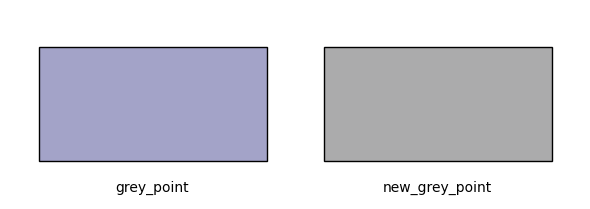

grey_point XYZ: [0.16775988 0.17344144 0.24727161]
grey_point RGB: [163 163 200]
new_grey_point XYZ: [0.17618996 0.19399527 0.17569914]
new_grey_point RGB: [171 171 172]


In [93]:
import numpy as np
import matplotlib.pyplot as plt

missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run prior cells first; missing: {missing}")

if "grey_point" not in globals():
    raise RuntimeError("`grey_point` is not defined. Run the earlier cell that computes the original grey point.")

new_grey_xyz = np.asarray(new_grey_point, dtype=float).reshape(1, 3)
old_grey_xyz = np.asarray(grey_point, dtype=float).reshape(1, 3)

new_grey_rgb = np.clip(cal.xyz_to_rgb(new_grey_xyz, clip=True, as_int=False)[0] / 255.0, 0.0, 1.0)
old_grey_rgb = np.clip(cal.xyz_to_rgb(old_grey_xyz, clip=True, as_int=False)[0] / 255.0, 0.0, 1.0)

fig, ax = plt.subplots(figsize=(6, 2.2))
ax.add_patch(plt.Rectangle((0.05, 0.2), 0.4, 0.6, color=old_grey_rgb, ec="black", lw=1.0))
ax.add_patch(plt.Rectangle((0.55, 0.2), 0.4, 0.6, color=new_grey_rgb, ec="black", lw=1.0))

ax.text(0.25, 0.1, "grey_point", ha="center", va="top", fontsize=10)
ax.text(0.75, 0.1, "new_grey_point", ha="center", va="top", fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.tight_layout()
plt.show()

print("grey_point XYZ:", old_grey_xyz[0])
print("grey_point RGB:", np.rint(old_grey_rgb * 255).astype(int))
print("new_grey_point XYZ:", new_grey_xyz[0])
print("new_grey_point RGB:", np.rint(new_grey_rgb * 255).astype(int))